**Welcome to your First Graded Assignment on Machine Learning!**

## Employee Churn Dataset

About the Data

This dataset contains information about employees in a company, including their educational backgrounds, work history, demographics, and employment-related factors. It has been anonymized to protect privacy while still providing valuable insights into the workforce.

Goal:- The classification goal is to predict if the Employee will Churn / Attrition (1 / 0) in the company.

Features of train data are listed below


1. **Education:** The educational qualifications of employees, including degree, institution, and field of study.

2. **Joining Year:** The year each employee joined the company, indicating their length of service.

3. **City:** The location or city where each employee is based or works.

4. **Payment Tier:** Categorization of employees into different salary tiers.

5. **Age:** The age of each employee, providing demographic insights.

6. **Gender:** Gender identity of employees, promoting diversity analysis.

7. **Ever Benched:** Indicates if an employee has ever been temporarily without assigned work.

8. **Experience in Current Domain:** The number of years of experience employees have in their current field.

Target Column

9. **Leave or Not:** Whether employee left us or Not (1 = Left)

---

**What is our Key target for ML?**

Are there any patterns in leave-taking behavior among employees?

You will find the answer to this question at EDA and also last stage of ML wher you interpret and find most influential features (Importance) to predict "Leave"


**Requirements: (TOTAL 75 Marks)**



**DATA CLEANING (5 Marks)**

Import data, Clean it and check necessary with steps, Look for Data Types & Duplicate.

The following Data Cleaning Steps need to be ensured:
- Make sure there is No Duplicate Data
- You do describe and Info for Null Values explore
- You transform Target Column 1 (Leave) and 0 as (Stay)

You need to conduct **Exploratory Data Analysis (Total Segment Marks (9 + 5 + 3) * 2 = 34 Marks** :

1. Univariate Analysis
- For All Variables

2. Bi Variate Analysis Against Target
- For 5 Important Variables you think

3. Multi Variate to Uncover Complex Relatinships
- For 3 Variables you think should be looked into combination

Format in General (Extend it)

- Analysis Cell (Your Code and Chart is here) 1 Marks
- Insight Cell (What did you learn from above Chart / Analysis) 1 Marks

---

Step 4 : **Features Preparation & Engineering (16 Marks)**

You shall need to treat Numerical and Categorical Variables to be Machine Learning model ready.

- Scale Numerical Values (2 Marks for Each Numerical Variable) : https://geekpython.in/how-to-use-sklearn-standardscaler

- One Hot Encode Categorical Values (2 Marks for Each Categorical Variable) : https://datasensei.medium.com/how-to-transform-nominal-data-for-ml-with-onehotencoder-from-scikit-learn-f6febfefb3c6

---

Step 5 : **Splitting Data for Training & Test Evaluation (3 Marks)**

Step 6 : **Model Building (Train 3 Models Logistic vs DT vs RF) (6 Marks)**

Step 7 : **Model Evaluation (Define a Metric you selected for the Problem) (4 Marks)**

* 1 Marks for Selection between Accuracy Recall or Precision
* 1 Marks for Reasoning
* 1 Marks for Evaluation Interpretation

(Compare Model Performance based on chosen Metric and Iterate between Step 7 - 8 to finalize the Best 1)

* 1 Marks for Selection of Best Model

---

Step 8 : **Testing the Model on (Splited Test Data) (2 Marks)**

- Interpret the Classification Report

(Comment on the Gap between Training and Testing Accuracy - is it overfit?)

---

Step 9 : **Interpretation & Learning from Modelling (5 Marks)**

Call in the RF / Logistic Model Important Feature Charts or Decision Tree Visualization to share insights on Learned Important Features / Rules of Classification of Employees of who leave us to answer the Ultimate Question.


**Good luck!**

### **Importing Data**

In [2]:
## Importing Required Libraries
import pandas as pd

## Reading the dataset
df = pd.read_csv("Employee.csv")

In [3]:
## CHECK AND DROP DUPLICATES AND RECALL MORE DATA CLEANING STEPS WHILE REQUIRED (DONT DROP NA)

# done in below cell


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

### **Data Cleaning**

In [5]:

# Before processing
df.info()
null_count =df.isnull().sum()
print(f"Number of N/A: {null_count}")
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
df = df.drop_duplicates()
print(f"Data shape after dropping duplicates: {df.shape}")

# After processing
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
 8   LeaveOrNot                 4653 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 327.3+ KB
Number of N/A: Education                    0
JoiningYear                  0
City                         0
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
Exper

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


In [6]:
df['LeaveStatus'] = df['LeaveOrNot'].map({1: 'Leave', 0: 'Stay'})

In [7]:
df.describe()

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot
count,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000
mean,2015.090449,2.636035,30.952967,2.644356,0.393632
std,1.885943,0.624001,5.108872,1.610610,0.488643
min,2012.000000,1.000000,22.000000,0.000000,0.000000
25%,2013.000000,2.000000,27.000000,1.000000,0.000000
50%,2015.000000,3.000000,30.000000,2.000000,0.000000
75%,2017.000000,3.000000,35.000000,4.000000,1.000000
max,2018.000000,3.000000,41.000000,7.000000,1.000000


### **Exploratory Data Analysis**

#### UNIVARIATE

In [8]:
## Python Pandas / Seaborn / Matplotlib Solution

In [9]:
def create_histogram_uni(df, var, bins=15, kde=True, cmap='viridis', title=None, xlabel=None, ylabel='Count', figsize=(10, 6)):
    # Create the histogram with gradient coloring
    plt.figure(figsize=figsize)
    hist = sns.histplot(
        data=df,
        x=var,
        bins=bins,
        kde=kde,
        palette=cmap,
        edgecolor=None
    )

    # Create a colormap and apply a color gradient
    counts, bin_edges = np.histogram(df[var].dropna(), bins=bins)
    norm = plt.Normalize(vmin=0, vmax=max(counts))
    for i, bar in enumerate(hist.patches):
        bar.set_facecolor(plt.cm.get_cmap(cmap)(norm(counts[i])))

    # Titles and labels
    plt.title(title or f'{var} Distribution')
    plt.xlabel(xlabel or var)
    plt.ylabel(ylabel)
    plt.show()

def create_bar_uni(df, var, title=None, xlabel=None, ylabel='Count', palette='pastel', figsize=(8, 6)):
    # Get sorted categories by count and calculate percentages
    category_counts = df[var].value_counts()
    sorted_categories = category_counts.index
    total_count = len(df)
    category_percentages = (category_counts / total_count) * 100

    # Plot
    plt.figure(figsize=figsize)
    ax = sns.countplot(data=df, x=var, order=sorted_categories, palette=palette)
    plt.title(title or f'{var} Distribution')
    plt.xlabel(xlabel or var)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)

    # Add labels on each bar
    for p, percentage in zip(ax.patches, category_percentages):
        ax.annotate(f'{p.get_height()} ({percentage:.1f}%)',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=10, color='black',
                    xytext=(0, 5), textcoords='offset points')

    return plt

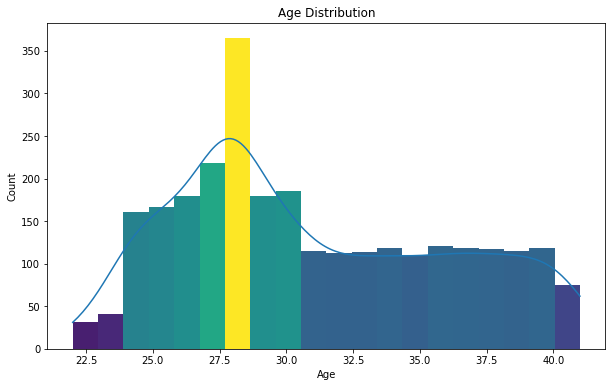

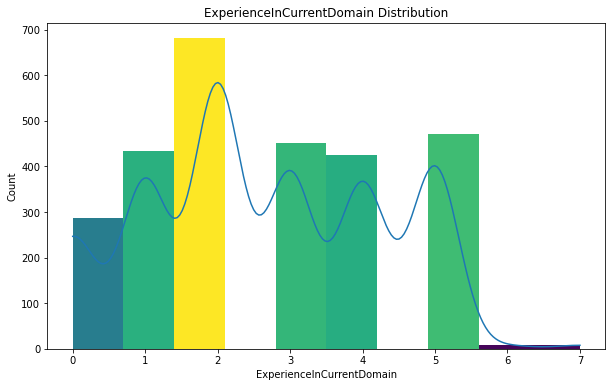

<module 'matplotlib.pyplot' from '/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/matplotlib/pyplot.py'>

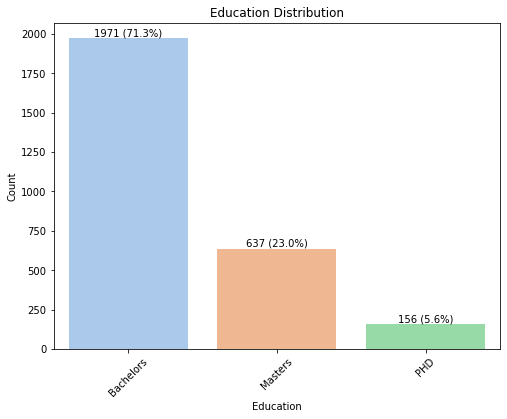

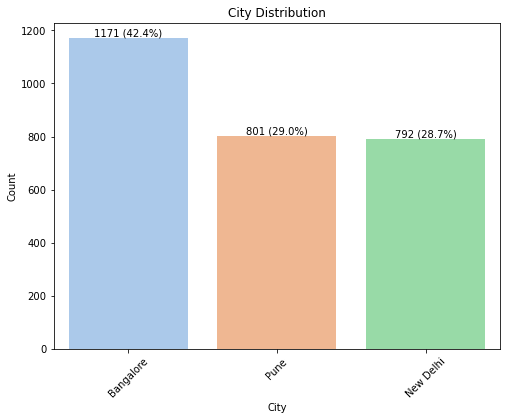

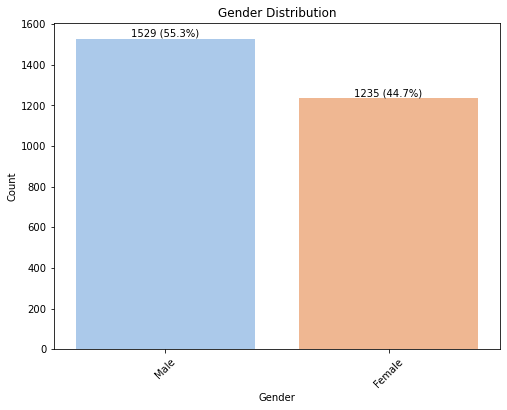

In [10]:
create_histogram_uni(df, 'Age', bins=20)
create_histogram_uni(df, 'ExperienceInCurrentDomain', bins=10)
create_bar_uni(df,'Education')
create_bar_uni(df,'City')
create_bar_uni(df,'Gender')


#### BI VARIATE

##### FIRST COMBINATION OF 2 VARS

In [11]:
## Python Pandas / Seaborn / Matplotlib Solution


def create_histogram_bi(df, var, hue=None, bins=20, kde=True, color='skyblue', title=None, xlabel=None, ylabel='Count', figsize=(10, 6)):
    # Set up the plot
    plt.figure(figsize=figsize)
    sns.histplot(data=df, x=var, hue=hue, bins=bins, kde=kde, color=color)

    # Set title and labels
    plt.title(title or f'{var} Distribution against {hue}')
    plt.xlabel(xlabel or var)
    plt.ylabel(ylabel)

    # Show plot
    plt.show()

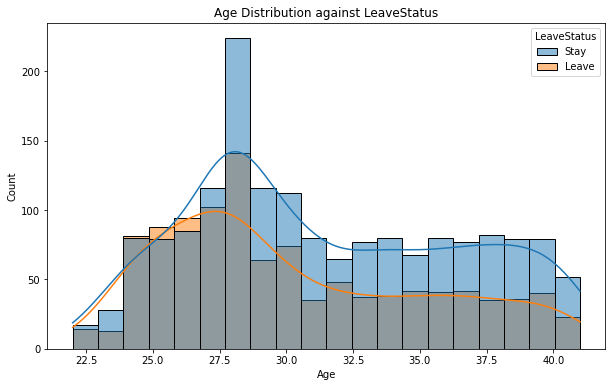

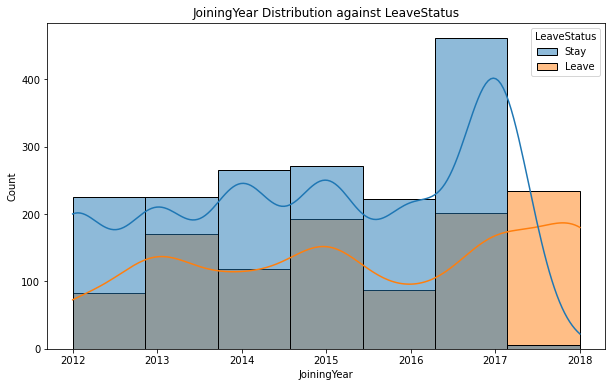

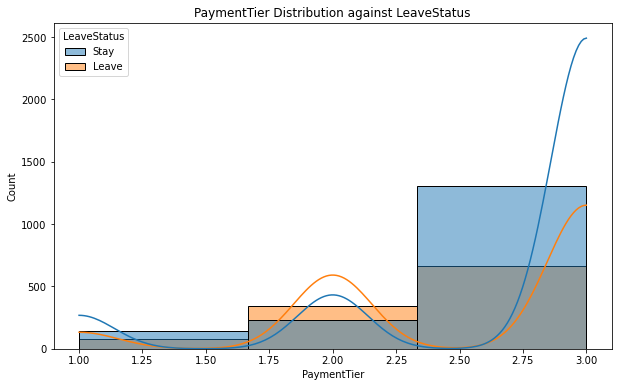

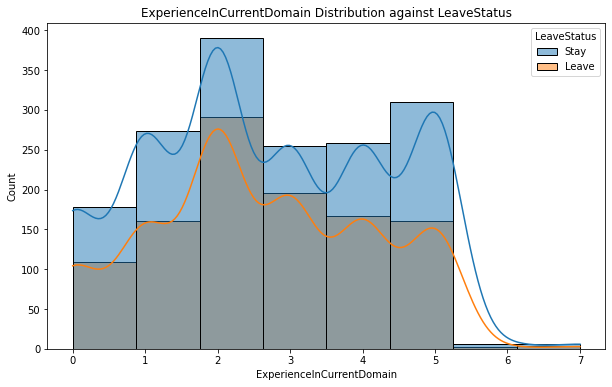

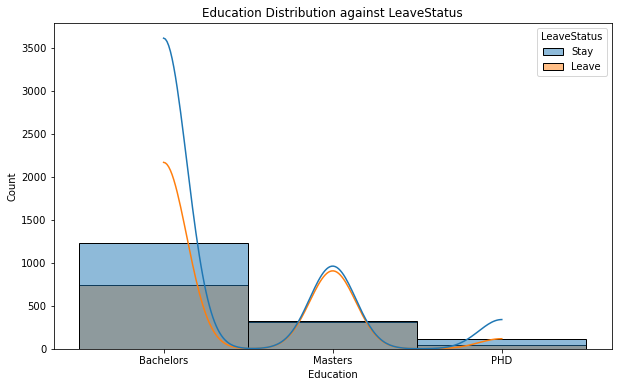

In [12]:
create_histogram_bi(df, var='Age', hue='LeaveStatus', bins=20)
create_histogram_bi(df, var='JoiningYear', hue='LeaveStatus', bins=7)
create_histogram_bi(df, var='PaymentTier', hue='LeaveStatus', bins=3)
create_histogram_bi(df, var='ExperienceInCurrentDomain', hue='LeaveStatus', bins=8)
create_histogram_bi(df, var='Education', hue='LeaveStatus', bins=3)

In [13]:
## Relevant Insight
Here are the one-line insights for each bivariate analysis:

Age vs LeaveStatus: Emplopyees Age between 25-30 shows high ratio of Leave the company. After 30 stability increases and les resignation or Leave.

JoiningYear vs LeaveStatus: As shown form graph in year 2018 most of the emmploye leave the company. This insight indicate the major internal issue of company.

PaymentTier vs LeaveStatus: From the 3rd graph plotted it shows Employees in Payment Tier 2 are moslty to leave as compared to the bottom and  top salary tiers employes.

Experience vs LeaveStatus: From 4th Graph it shows that employees having experience 2 - 3 years most likely to leave.

Education vs LeaveStatus: As shown in 5th Graph Employee with Masters degree haveing higher leave rate than Bachelors holders and PhD.

SyntaxError: invalid syntax (117011212.py, line 2)

#### MULTI VARIATE

##### FIRST COMBINATION OF MORE THAN 2 VARS



In [14]:
## Python Pandas / Seaborn / Matplotlib Solution
import seaborn as sns
import matplotlib.pyplot as plt

def create_multivariate_plot(df, x_var, col_var, hue_var='LeaveStatus', bins=30, palette='pastel'):
    g = sns.FacetGrid(df, col=col_var,hue=hue_var, height=5)

    g.map_dataframe(sns.histplot, x=x_var, bins=bins, kde=True, palette=palette, alpha=0.6)

    g.set_titles(col_template="{col_name}")

    g.set_axis_labels(x_var, "Count")

    g.add_legend(title=hue_var, loc='upper right')

    plt.show()

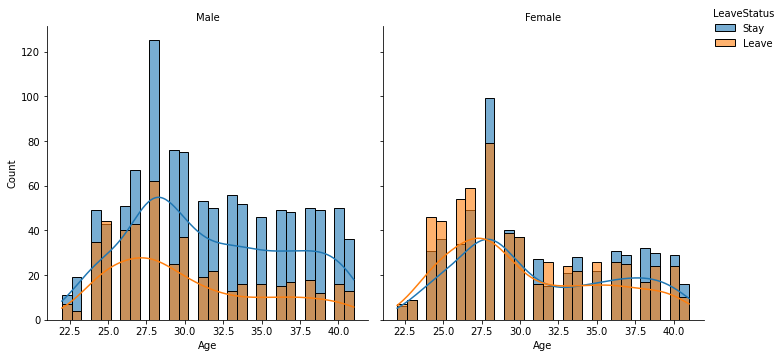

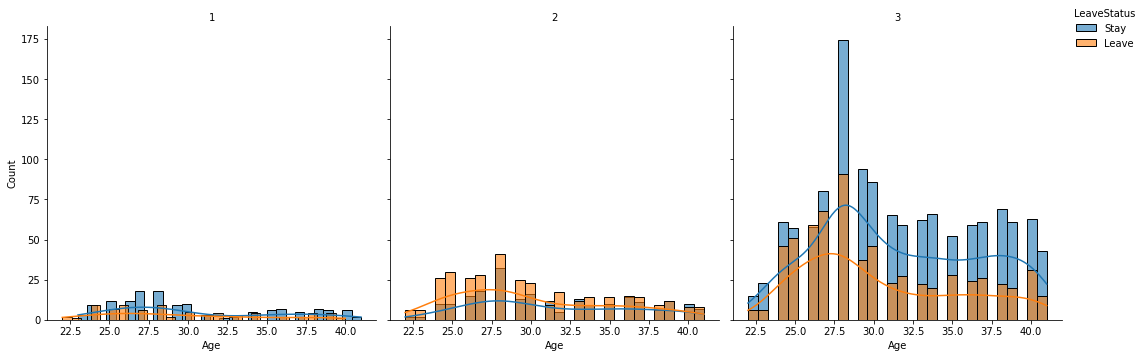

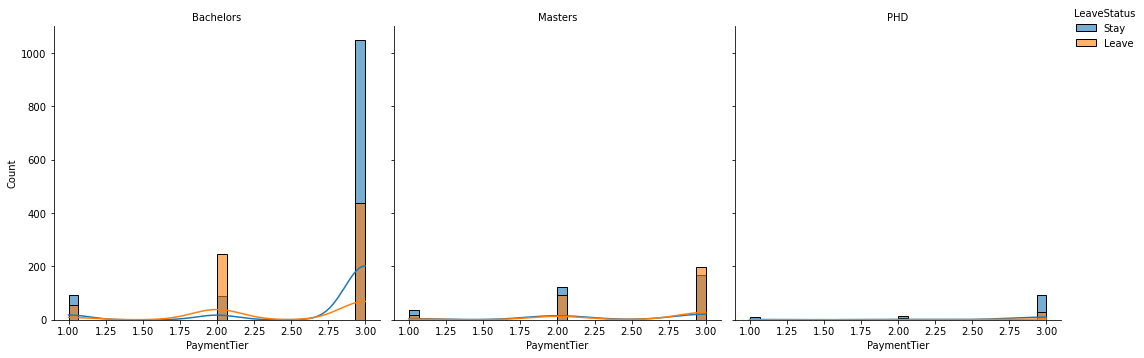

In [15]:
create_multivariate_plot(df, x_var='Age', col_var='Gender')
create_multivariate_plot(df, x_var='Age', col_var='PaymentTier')
create_multivariate_plot(df, x_var='PaymentTier', col_var='Education')

In [16]:
## Relevant Insight

#Age vs Gender vs Leave status: As shown form the first graph, the female employees have high leave status than male of same age bracket 24-28.(may be due to marriage)

#Age vs PaymentTier vs Leave Status:The second graph shows that Employees of age between 25-28 having the payment tier 2 have high chances to leave as compared to other age group and payment tiers.

#PaymentTier vs Education vs LeaveStatus: Third graph shows that , employee having the Master degree with payment tier 2 the highest leave status.(Due to specialized skill with Mid payment Tier)

### **Feature Engineering**

In [17]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import pandas as pd

# For Numerical columns
scaler = MinMaxScaler()

df['Age'] = scaler.fit_transform(df[['Age']])
df['JoiningYear'] = scaler.fit_transform(df[['JoiningYear']])
df['ExperienceInCurrentDomain'] = scaler.fit_transform(df[['ExperienceInCurrentDomain']])
df['PaymentTier'] = scaler.fit_transform(df[['PaymentTier']])


# For Categorical Columns
enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform="pandas")

encoded_edu = enc.fit_transform(df[['Education']])
encoded_city = enc.fit_transform(df[['City']])
encoded_gender = enc.fit_transform(df[['Gender']])
encoded_bench = enc.fit_transform(df[['EverBenched']])


X_encoded = pd.concat([df[['Age', 'JoiningYear', 'ExperienceInCurrentDomain', 'PaymentTier']], 
                      encoded_edu, encoded_city, encoded_gender, encoded_bench], axis=1)

y = df['LeaveOrNot']
X_encoded.head()



,Age,JoiningYear,ExperienceInCurrentDomain,PaymentTier,Education_Bachelors,Education_Masters,Education_PHD,City_Bangalore,City_New Delhi,City_Pune,Gender_Female,Gender_Male,EverBenched_No,EverBenched_Yes
0,0.631579,0.833333,0.000000,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
1,0.315789,0.166667,0.428571,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
2,0.842105,0.333333,0.285714,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,0.263158,0.666667,0.714286,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
4,0.105263,0.833333,0.285714,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


### **Spliting the data**

In [18]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print(f"Train Data shape: {X_train.shape}")
print(f"Test Data shape:  {X_test.shape}")
print(f"y_Train Data shape: {y_train.shape}")
print(f"y_Test Data shape:  {y_test.shape}")


Train Data shape: (2211, 14)
Test Data shape:  (553, 14)
y_Train Data shape: (2211,)
y_Test Data shape:  (553,)


### **Model Creation & Training**

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Selection
clf = LogisticRegression(random_state=42)
model_DT = DecisionTreeClassifier(random_state=42)
model_RF = RandomForestClassifier(n_estimators=100, random_state=42)

clf.fit(X_train, y_train)
model_DT.fit(X_train, y_train)
model_RF.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

### **Model Evaluation**

In [20]:
# Model Evaluation
from sklearn.metrics import accuracy_score, balanced_accuracy_score


# Training Performance
y_train_pred = clf.predict(X_train)

training_accuracy = accuracy_score(y_pred=y_train_pred, y_true=y_train)
print("Accuracy:", training_accuracy)

training_balanced_accuracy = balanced_accuracy_score(y_pred=y_train_pred, y_true=y_train)
print("Balanced Accuracy:", training_balanced_accuracy)

# Testing Performance (Added in your style)
y_test_pred = clf.predict(X_test)

testing_accuracy = accuracy_score(y_pred=y_test_pred, y_true=y_test)
print("Testing Accuracy:", testing_accuracy)

testing_balanced_accuracy = balanced_accuracy_score(y_pred=y_test_pred, y_true=y_test)
print("Testing Balanced Accuracy:", testing_balanced_accuracy)
print("\n\r" )




y_train_pred_DT = model_DT.predict(X_train)

training_accuracy_DT = accuracy_score(y_pred=y_train_pred_DT, y_true=y_train)
print("Accuracy_model_DT:", training_accuracy_DT)

training_balanced_accuracy_DT = balanced_accuracy_score(y_pred=y_train_pred_DT, y_true=y_train)
print("Balanced Accuracy_mode_DT:", training_balanced_accuracy_DT)

# Testing Performance (Added in your style)
y_test_pred_DT = model_DT.predict(X_test)

testing_accuracy_DT = accuracy_score(y_pred=y_test_pred_DT, y_true=y_test)
print("Testing Accuracy_model_DT:", testing_accuracy_DT)

testing_balanced_accuracy_DT = balanced_accuracy_score(y_pred=y_test_pred_DT, y_true=y_test)
print("Testing Balanced Accuracy_model_DT:", testing_balanced_accuracy_DT)
print("\n\r" )



y_train_pred_RF = model_RF.predict(X_train)

training_accuracy_RF = accuracy_score(y_pred=y_train_pred_RF, y_true=y_train)
print("Accuracy_model_RF:", training_accuracy_RF)

training_balanced_accuracy_RF = balanced_accuracy_score(y_pred=y_train_pred_RF, y_true=y_train)
print("Balanced Accuracy_mode_RF:", training_balanced_accuracy_RF)

# Testing Performance (Added in your style)
y_test_pred_RF = model_RF.predict(X_test)

testing_accuracy_RF = accuracy_score(y_pred=y_test_pred_RF, y_true=y_test)
print("Testing Accuracy_model_RF:", testing_accuracy_RF)

testing_balanced_accuracy_RF = balanced_accuracy_score(y_pred=y_test_pred_RF, y_true=y_test)
print("Testing Balanced Accuracy_model_RF:", testing_balanced_accuracy_RF)
print("\n\r" )

Accuracy: 0.6843057440072365
Balanced Accuracy: 0.6382660046460397
Testing Accuracy: 0.6925858951175407
Testing Balanced Accuracy: 0.6537401037401037


Accuracy_model_DT: 0.9353233830845771
Balanced Accuracy_mode_DT: 0.9176267281105991
Testing Accuracy_model_DT: 0.6708860759493671
Testing Balanced Accuracy_model_DT: 0.6596300846300847


Accuracy_model_RF: 0.9353233830845771
Balanced Accuracy_mode_RF: 0.9255724339552072
Testing Accuracy_model_RF: 0.7233273056057866
Testing Balanced Accuracy_model_RF: 0.7024024024024024




In [21]:
# YOUR COMMENTS

# =========================================================================
# MODEL INTERPRETATION AND CONCLUSION
# =========================================================================
# - The first model Logistic regression, it shows stable balanced accuracy 
#   (63.83% Train / 65.37% Test), and test accuracy (69.26%). the model is 
#   linear it cannot fully capture all the patterns of the dataset, which 
#   shows the dataset have some nonlinear or complex features.
#
# - In other hand the remaining both model DT and RF shows overfitting , 
#   because the diffrence in train and test accuracies are very large, both 
#   models trayng to memorize the the patterns of the model.Inshort DT overfit 
#   severly as compared to RF, because DT splits nodes continuously until its 
#   leaves are completely pure or contain isolated data points.  The model RF 
#   also shows the Overfitting but it exhibit more balanced accuracy for train 
#   (92.56%) and test (70.24%) by ensemble the more trees than DT. which also 
#   deals better the class imbalance in RF.
#
# In my opininon on the basis of seeing reults i will rank the model.
# on first RF is winner for us [Highest test balanced accuracy and robust against class imbalance]
# on second Decision Tree [Overfits severely, but still holds higher test predictive power than LR]
# on third Linear Regression [Stable, but mathematically lacks the capacity to capture dataset patterns]

### **Model Prediction**

=== Model: Logistic Regression ===
Training Accuracy: 0.6843057440072365
Training Confusion Matrix:
[[1145  198]
 [ 500  368]]
------------------------------
Testing Accuracy: 0.6925858951175407
Testing Confusion Matrix:
[[281  52]
 [118 102]]
------------------------------


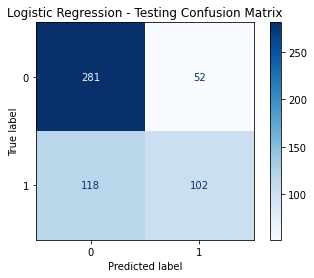



=== Model: Random Forest ===
Training Accuracy: 0.9353233830845771
Training Confusion Matrix:
[[1304   39]
 [ 104  764]]
------------------------------
Testing Accuracy: 0.7233273056057866
Testing Confusion Matrix:
[[268  65]
 [ 88 132]]
------------------------------


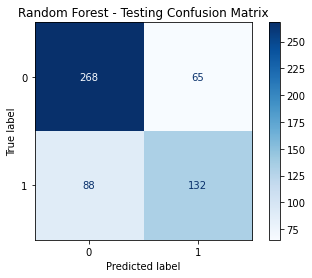



=== Model: Decision Tree ===
Training Accuracy: 0.9353233830845771
Training Confusion Matrix:
[[1343    0]
 [ 143  725]]
------------------------------
Testing Accuracy: 0.6708860759493671
Testing Confusion Matrix:
[[238  95]
 [ 87 133]]
------------------------------


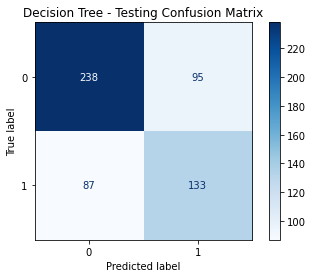

In [22]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression  # Added to prevent missing import error
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Initialize classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

# Model Evaluation Loop
for name, clf in classifiers.items():
    print(f"=== Model: {name} ===")
    
    # 1. Model Training
    clf.fit(X_train, y_train)

    # =========================================================================
    # PART A: TRAINING DATA EVALUATION
    # =========================================================================
    y_train_pred = clf.predict(X_train)

    # Evaluate the classifier on Training data
    train_accuracy = accuracy_score(y_true=y_train, y_pred=y_train_pred)
    print("Training Accuracy:", train_accuracy)

    # Text Confusion matrix for Training data
    print("Training Confusion Matrix:")
    print(confusion_matrix(y_true=y_train, y_pred=y_train_pred))
    print("-" * 30)

    # =========================================================================
    # PART B: TESTING DATA EVALUATION (Added)
    # =========================================================================
    y_test_pred = clf.predict(X_test)

    # Evaluate the classifier on Testing data
    test_accuracy = accuracy_score(y_true=y_test, y_pred=y_test_pred)
    print("Testing Accuracy:", test_accuracy)

    # Text Confusion matrix for Testing data
    print("Testing Confusion Matrix:")
    print(confusion_matrix(y_true=y_test, y_pred=y_test_pred))
    print("-" * 30)

    # =========================================================================
    # PART C: PLOTTING TEST CONFUSION MATRIX ON CELL
    # =========================================================================
    # Testing data ka matrix plot karna zyada important hota hai taake real performance dikhe
    cm_test = confusion_matrix(y_true=y_test, y_pred=y_test_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=clf.classes_)
    disp.plot(cmap='Blues') # Beautiful blue shade representation
    plt.title(f"{name} - Testing Confusion Matrix")
    plt.show() # Directly cell par graph display karne ke liye
    
    print("\n" + "="*50 + "\n")

### **Model Training Accuracy Report**

In [23]:
# Model Evaluation
for name, clf in classifiers.items():
    print(f"Model: {name}")
    # Model Training
    clf.fit(X_train, y_train)

    # Model Evaluation
    y_train_pred = clf.predict(X_train)

    # Evaluate the classifier
    accuracy = accuracy_score(y_train, y_train_pred)
    print("Accuracy:", accuracy)

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_train, y_train_pred))

    print("\n-------------------------------------\n")

Model: Logistic Regression
Accuracy: 0.6843057440072365

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.85      0.77      1343
           1       0.65      0.42      0.51       868

    accuracy                           0.68      2211
   macro avg       0.67      0.64      0.64      2211
weighted avg       0.68      0.68      0.67      2211


-------------------------------------

Model: Random Forest
Accuracy: 0.9353233830845771

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      1343
           1       0.95      0.88      0.91       868

    accuracy                           0.94      2211
   macro avg       0.94      0.93      0.93      2211
weighted avg       0.94      0.94      0.93      2211


-------------------------------------

Model: Decision Tree
Accuracy: 0.9353233830845771

Classification Report:
              precision    recall  f1-

In [24]:
# YOUR COMMENTS

# - Accuracy: total number of correct predictions on both classes, misleading due to class imbalance. 
#- Precision: Correctly predicting positive cases and not raising false alarms for Stay (0) or Leave (1).
#- Recall: The ability to find all the actual cases. Make sure, that we are not missing out employees who Stay (0) or Leave (1). 
#- F1-Score: Complete best balanced score of Precision and Recall for both classes.

### **Model Interpretation & Key Learnings**

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


features = X_encoded.columns

sns.set_theme(style="whitegrid", font_scale=1.1)

# =========================================================================
# 1. LOGISTIC REGRESSION (Coefficients / Weights)
# =========================================================================
importances_lr = clf.coef_[0]
importance_df_lr = pd.DataFrame({'Feature': features, 'Importance': importances_lr})
importance_df_lr = importance_df_lr.sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
# FIXED: Removed hue and legend parameters to support older Seaborn versions
sns.barplot(x='Importance', y='Feature', data=importance_df_lr, palette='coolwarm', ax=ax)

ax.set_title('Logistic Regression - Feature Coefficients', fontsize=16, pad=15, fontweight='bold')
ax.set_xlabel('Coefficient Value (Direction & Weight)', fontsize=12, labelpad=10)
ax.set_ylabel('Dataset Features', fontsize=12, labelpad=10)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


# =========================================================================
# 2. DECISION TREE FEATURE IMPORTANCE
# =========================================================================
importances_dt = model_DT.feature_importances_
importance_df_dt = pd.DataFrame({'Feature': features, 'Importance': importances_dt})
importance_df_dt = importance_df_dt.sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
# FIXED: Removed hue and legend parameters to prevent AttributeError
sns.barplot(x='Importance', y='Feature', data=importance_df_dt, palette='viridis', ax=ax)

ax.set_title('Decision Tree - Feature Importances', fontsize=16, pad=15, fontweight='bold')
ax.set_xlabel('Importance Score (Relative Contribution)', fontsize=12, labelpad=10)
ax.set_ylabel('Dataset Features', fontsize=12, labelpad=10)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


# =========================================================================
# 3. RANDOM FOREST FEATURE IMPORTANCE
# =========================================================================
importances_rf = model_RF.feature_importances_
importance_df_rf = pd.DataFrame({'Feature': features, 'Importance': importances_rf})
importance_df_rf = importance_df_rf.sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
# FIXED: Cleaned for compatibility with your local environment
sns.barplot(x='Importance', y='Feature', data=importance_df_rf, palette='viridis', ax=ax)

ax.set_title('Random Forest - Feature Importances', fontsize=16, pad=15, fontweight='bold')
ax.set_xlabel('Importance Score (Relative Contribution)', fontsize=12, labelpad=10)
ax.set_ylabel('Dataset Features', fontsize=12, labelpad=10)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

AttributeError: 'DecisionTreeClassifier' object has no attribute 'coef_'

In [26]:
# YOUR COMMENTS

#The empolyee is leaving or stay is not just as easy to predict by seeing single feature of dataset.
#It is complex and nonlinear task.
#As seen fromt the above feature inoirtance graph which shows that which feature ontribute most in prediction of Empolyee leave or stay in each ML model.
#The goruped of feaures/complex pattern based on these features use , some features contirbute most like joining year contribute high in all all three models.

# - Logistic Regression: Shows the +ve or -ve direction of each feature's impact on churn,
# - Decision Tree: Ranks features based on impurity reduction, but heavily over-focuses on a few 
#   specific boundaries (like Age or JoiningYear), which making it memorize the patter and shows overfitting.
# - Random Forest: Provides the most reliable ranking by averaging importance across 100 different 
#   trees, resulting in a smoother, more realistic distribution that captures true non-linear patterns.


In [27]:


from sklearn.model_selection import train_test_split

# 1. Identify raw feature types exactly matching your dataset columns
categorical_features = ['Education', 'City', 'Gender', 'EverBenched']
numerical_features = ['Age', 'JoiningYear', 'ExperienceInCurrentDomain', 'PaymentTier']

# 2. Separate into features (X) and target variable (y)
X_raw = df[categorical_features + numerical_features]
y = df['LeaveOrNot']

# 3. Split into training and testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)

print(f"Raw Train shape: {X_train.shape}")
print(f"Raw Test shape:  {X_test.shape}")

Raw Train shape: (2211, 8)
Raw Test shape:  (553, 8)


In [28]:
import pickle
import pandas as pd

# Helper function from the source file to summarize categorical values
def summarize_cat(data, categorical_features):
    results = []
    for column in data[categorical_features]:
        members = data[column].unique().tolist()
        results.append([column, members])
    return pd.DataFrame(results, columns=['Column Name', 'Members'])

# Create the exact metadata structure used by Data Engineering
my_feature_dict = {
    'CATEGORICAL': summarize_cat(X_train, categorical_features).to_dict(), 
    'NUMERICAL': {'Column Name': numerical_features}
}

# Save the feature dictionary to a pickle file
with open('my_feature_dict.pkl', 'wb') as fp:
    pickle.dump(my_feature_dict, fp)
    print('Dictionary saved successfully to file: my_feature_dict.pkl')

# Display the dictionary to inspect
my_feature_dict

Dictionary saved successfully to file: my_feature_dict.pkl


{'CATEGORICAL': {'Column Name': {0: 'Education',
   1: 'City',
   2: 'Gender',
   3: 'EverBenched'},
  'Members': {0: ['Bachelors', 'Masters', 'PHD'],
   1: ['Bangalore', 'New Delhi', 'Pune'],
   2: ['Male', 'Female'],
   3: ['No', 'Yes']}},
 'NUMERICAL': {'Column Name': ['Age',
   'JoiningYear',
   'ExperienceInCurrentDomain',
   'PaymentTier']}}

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Numerical Transformer Pipeline (Scaling + Imputation)
pipeline_num = Pipeline(steps=[
    ('scale_data', StandardScaler()),
    ('simple_imputer1', SimpleImputer(strategy='constant', fill_value=0)),
])

# Categorical Transformer Pipeline (One-Hot Encoding)
pipeline_cat = Pipeline(steps=[
    ('OneHotEncode', OneHotEncoder(handle_unknown="ignore"))
])

# Combine into a final preprocessor layout matching the source design pattern
preprocessor_stack = ColumnTransformer(
    transformers=[
        ('cat', pipeline_cat, categorical_features),
        ('num', pipeline_num, numerical_features),
    ], remainder='drop'
)

print("Preprocessing pipeline stack created successfully.")

Preprocessing pipeline stack created successfully.


In [30]:
from sklearn.ensemble import RandomForestClassifier

# Create the main master pipeline combining preprocessing and classification steps
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_stack),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Fit the entire pipeline on your raw training records
pipeline.fit(X_train, y_train)
print("Pipeline fitted successfully on training data!")

Pipeline fitted successfully on training data!


In [31]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the training data
y_train_pred = pipeline.predict(X_train)

# Evaluate training metrics
print("=== Training Performance ===")
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_train, y_train_pred))

=== Training Performance ===
Accuracy: 0.9353233830845771

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95      1343
           1       0.96      0.88      0.91       868

    accuracy                           0.94      2211
   macro avg       0.94      0.92      0.93      2211
weighted avg       0.94      0.94      0.93      2211


Confusion Matrix:
 [[1308   35]
 [ 108  760]]


In [32]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the testing split
y_test_pred = pipeline.predict(X_test)

# Evaluate testing metrics
print("=== Testing Performance ===")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

=== Testing Performance ===
Accuracy: 0.7269439421338155

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.80      0.78       333
           1       0.67      0.61      0.64       220

    accuracy                           0.73       553
   macro avg       0.72      0.71      0.71       553
weighted avg       0.72      0.73      0.72       553


Confusion Matrix:
 [[267  66]
 [ 85 135]]


In [33]:
import dill

# Save the completely trained pipeline object into a .pkl binary file
with open('pipeline_class.pkl', 'wb') as file:
    dill.dump(pipeline, file)

print('Pipeline saved successfully to file: pipeline.pkl')

Pipeline saved successfully to file: pipeline.pkl


In [34]:
pip install dill

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.
